# Module "Alerte Suivi Glycémique" — Prédiction du résultat du test HbA1c

## Contexte clinique : pourquoi l'HbA1c est un indicateur central du suivi du diabète

L'**hémoglobine glyquée (HbA1c)** est un examen sanguin qui mesure la quantité de sucre fixée sur l'hémoglobine des globules rouges. Contrairement à une glycémie ponctuelle, qui ne reflète que l'instant du prélèvement, l'HbA1c donne une **moyenne du taux de sucre sur les 2 à 3 derniers mois** — la durée de vie d'un globule rouge. C'est l'examen de référence recommandé par les sociétés savantes internationales (OMS, American Diabetes Association) pour suivre l'équilibre d'un patient diabétique dans la durée.

Un diabète mal contrôlé sur le long terme abîme progressivement les vaisseaux sanguins, ce qui mène aux complications classiques de la maladie : atteintes rénales, rétiniennes, nerveuses et cardiovasculaires. Plus un déséquilibre est détecté et corrigé tôt, moins ces complications ont de chances de se développer — d'où l'importance de ne jamais laisser un patient diabétique hospitalisé sans ce point de contrôle.

L'exploration du jeu de données révèle un constat frappant : **plus de 80 % des patients diabétiques hospitalisés n'ont pas eu de test HbA1c réalisé pendant leur séjour**. Cela représente une occasion de dépistage manquée à grande échelle — un moment où le patient est présent et suivi, mais où son équilibre glycémique de fond n'est pas vérifié.



Ce module couvre l'unique axe **préventif** de l'application : repérer, dès l'admission, les patients dont le suivi glycémique risque d'être insuffisant ou de révéler un mauvais contrôle du diabète — avant qu'ils ne sortent sans avoir été correctement dépistés.

## Besoin métier

> Identifier, dès l'admission, les patients diabétiques dont le suivi glycémique (test HbA1c) risque d'être insuffisant ou de révéler un mauvais contrôle du diabète, afin de cibler en priorité les actions de suivi médical et de prévention, et de déclencher le bon examen au bon moment.

## Besoin Data Science

> Construire un modèle de classification supervisée qui prédit le résultat du test HbA1c à partir des informations cliniques et démographiques disponibles pour le patient, où la cible est la variable `A1Cresult` du jeu de données.

## Le service rendu par le modèle

Le modèle ne remplace à aucun moment le jugement médical : il agit comme un **filet de sécurité automatisé**, à trois niveaux :

1. **En amont du test** : il identifie, dès l'admission, les profils de patients ayant statistiquement le plus de risques d'un mauvais contrôle glycémique ou d'une absence de dépistage, pour déclencher une vérification ciblée plutôt qu'un dépistage au hasard.
2. **Priorisation des ressources** : un service hospitalier ne peut pas tester systématiquement tous les patients. Le modèle concentre l'attention des équipes sur les cas à risque le plus élevé.
3. **Filet de rattrapage avant la sortie** : si un patient signalé à risque n'a toujours pas de test réalisé en fin de séjour, c'est un signal pour l'équipe médicale de ne pas le laisser sortir sans ce point de contrôle.

## Pourquoi cette cible

`A1Cresult` est une variable native du jeu de données : ses valeurs possibles existent déjà telles quelles dans les données brutes, sans transformation préalable. Le travail de préparation porte uniquement sur les variables explicatives (features), jamais sur la fabrication de la cible elle-même.

## Plan du notebook

1. Chargement et exploration des données
2. Analyse de la variable cible `A1Cresult` et simplification en 3 classes
3. Data Cleaning
4. Feature Selection
5. Data Transforms
6. Feature Engineering
7. Dimensionality Reduction (discussion)
8. Split train/test et modèle de référence
9. Évaluation
10. Optimisation du modèle (GridSearchCV, SMOTE) et comparaison finale


## 1. Chargement et exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)

# IMPORTANT : keep_default_na=False empêche pandas de transformer le texte littéral
# "None" (qui signifie ici "test non réalisé") en valeur manquante NaN.
# Vérifié au préalable : aucune autre colonne du dataset n'utilise ce mot comme texte,
# donc ce paramètre n'a pas d'effet de bord ailleurs.
df = pd.read_csv('diabetic_data.csv', keep_default_na=False)
print("Dimensions :", df.shape)
df.head()


Dimensions : (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [3]:
# Pourcentage de valeurs manquantes marquées '?' (le vrai marqueur de manquant dans ce dataset)
missing = (df == '?').sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'nb_manquants': missing, 'pct_manquants': missing_pct})


,nb_manquants,pct_manquants
weight,98569,96.9
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0


## 2. Analyse de la variable cible `A1Cresult`

Aucune construction n'est nécessaire : on observe directement la colonne telle qu'elle existe dans les données.

In [4]:
print(df['A1Cresult'].value_counts())
print()
print((df['A1Cresult'].value_counts(normalize=True) * 100).round(1))


A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

A1Cresult
None    83.3
>8       8.1
Norm     4.9
>7       3.7
Name: proportion, dtype: float64


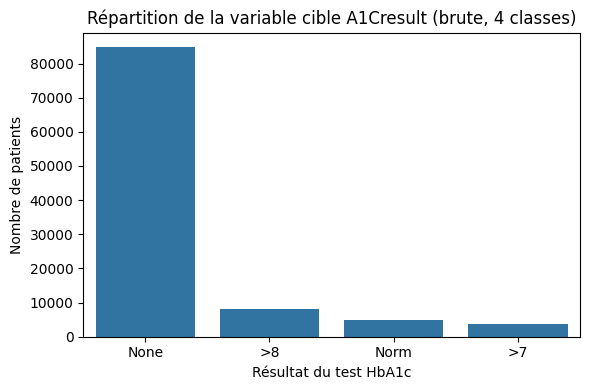

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='A1Cresult', order=df['A1Cresult'].value_counts().index)
plt.title("Répartition de la variable cible A1Cresult (brute, 4 classes)")
plt.ylabel("Nombre de patients")
plt.xlabel("Résultat du test HbA1c")
plt.tight_layout()
plt.show()


**Interprétation :** environ 83 % des patients n'ont pas eu de test HbA1c réalisé pendant leur séjour (`None`). Parmi ceux qui l'ont eu, la majorité ont un résultat élevé (`>8`), ce qui signale un mauvais contrôle du diabète. Les classes sont donc très déséquilibrées — un point à gérer explicitement lors de la modélisation.

C'est aussi, en soi, un premier résultat métier intéressant à présenter : **la majorité des patients diabétiques hospitalisés ne sont pas dépistés**, ce qui renforce la pertinence du besoin métier énoncé en introduction.

### 2.1 Simplification de la cible : 4 classes → 3 classes

La variable brute distingue 4 valeurs : `None`, `Norm`, `>7`, `>8`. Or `>7` et `>8` sont deux classes minoritaires et cliniquement proches — toutes deux signalent un mauvais contrôle du diabète — ce qui les rend faciles à confondre entre elles et difficiles à bien distinguer avec peu d'exemples.

**Choix retenu :** fusionner `>7` et `>8` en une seule classe `Anormal`. Cliniquement, la distinction fine entre "modérément élevé" et "élevé" est moins actionnable pour le besoin métier ("faut-il intervenir ?") qu'une distinction claire **Non testé / Normal / Anormal**. On passe ainsi d'un problème à 4 classes à un problème à 3 classes, plus simple et plus robuste.

In [6]:
def merge_target(value):
    if value in ['>7', '>8']:
        return 'Anormal'
    return value  # 'None' et 'Norm' restent inchangés

df['A1C_target'] = df['A1Cresult'].apply(merge_target)

print(df['A1C_target'].value_counts())
print()
print((df['A1C_target'].value_counts(normalize=True) * 100).round(1))


A1C_target
None       84748
Anormal    12028
Norm        4990
Name: count, dtype: int64

A1C_target
None       83.3
Anormal    11.8
Norm        4.9
Name: proportion, dtype: float64


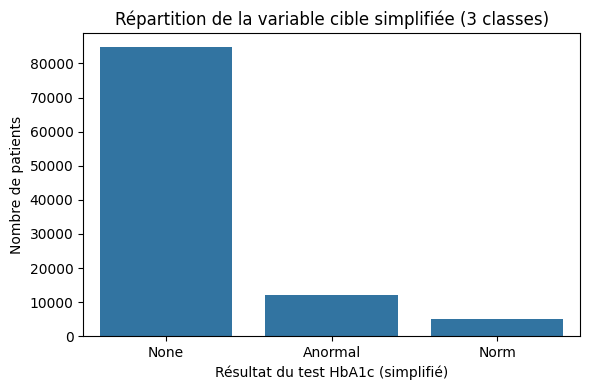

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='A1C_target', order=df['A1C_target'].value_counts().index)
plt.title("Répartition de la variable cible simplifiée (3 classes)")
plt.ylabel("Nombre de patients")
plt.xlabel("Résultat du test HbA1c (simplifié)")
plt.tight_layout()
plt.show()


**Remarque méthodologique :** cette fusion reste une simplification d'une cible déjà existante, pas une construction de cible à partir de plusieurs colonnes différentes. Regrouper deux modalités proches d'une même variable (ici `>7` et `>8`) est une opération standard en classification, comparable au regroupement de tranches d'âge ou de notes voisines. La variable reste `A1Cresult`, seule sa granularité change.

## 3. Data Cleaning

### 3.1 Doublons patients

On ne garde que le premier épisode de chaque patient, pour éviter toute fuite d'information entre train et test.

In [8]:
print("Nombre de patient_nbr dupliqués avant nettoyage :", df['patient_nbr'].duplicated().sum())

df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()

print("Dimensions après dédoublonnage patients :", df.shape)
print()
print(df['A1C_target'].value_counts())


Nombre de patient_nbr dupliqués avant nettoyage : 30248
Dimensions après dédoublonnage patients : (71518, 51)

A1C_target
None       58532
Anormal     9195
Norm        3791
Name: count, dtype: int64


### 3.2 Suppression des colonnes trop incomplètes ou non pertinentes

- `weight` : ~96 % de valeurs manquantes → non récupérable
- `payer_code` : ~43 % de manquants, pas de lien logique avec le résultat d'un examen biologique
- `encounter_id` : identifiant technique, aucune valeur prédictive

In [9]:
cols_to_drop = ['weight', 'payer_code', 'encounter_id']
df = df.drop(columns=cols_to_drop)
df.shape


(71518, 48)

### 3.3 Traitement des valeurs manquantes restantes

In [10]:
# medical_specialty et diag_1/2/3 : on remplace '?' par une catégorie explicite 'Missing'
for col in ['medical_specialty', 'diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].replace('?', 'Missing')

# race : peu de manquants -> imputation par la modalité la plus fréquente
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values='?', strategy='most_frequent')
df['race'] = imputer.fit_transform(df[['race']]).ravel()

remaining = (df == '?').sum()
remaining[remaining > 0]


Series([], dtype: int64)

### 3.4 Colonnes à variance quasi nulle

In [11]:
near_constant = [col for col in df.columns if df[col].nunique() <= 1]
print("Colonnes constantes détectées :", near_constant)
df = df.drop(columns=near_constant)
df.shape


Colonnes constantes détectées : ['examide', 'citoglipton', 'glimepiride-pioglitazone']


(71518, 45)

### 3.5 Outliers

Les valeurs extrêmes de variables comme `num_medications` ou `number_emergency` reflètent une vraie charge clinique et ne sont pas des erreurs de mesure. On ne les cappe pas.

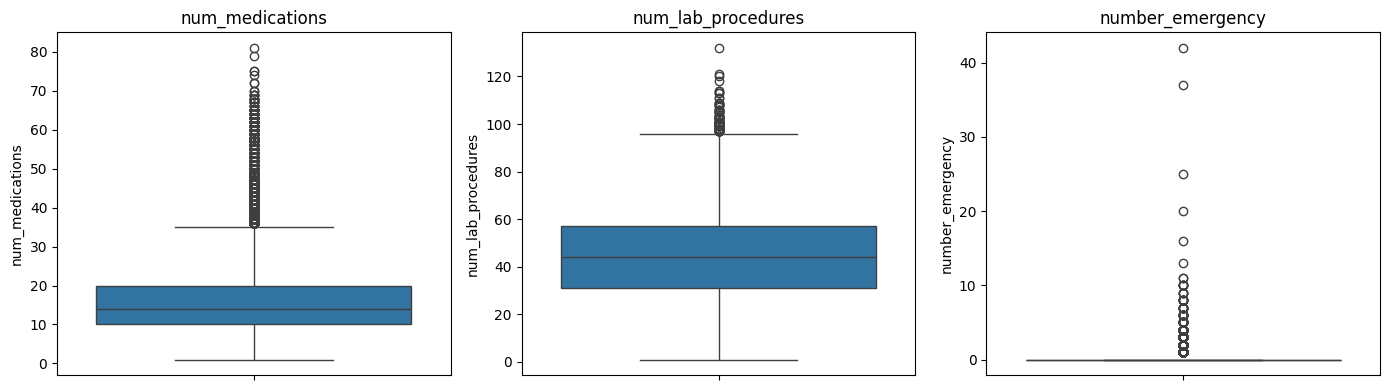

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['num_medications', 'num_lab_procedures', 'number_emergency']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Feature Selection

On sépare la cible des variables explicatives, et on retire les identifiants techniques.

In [13]:
y = df['A1C_target']
X = df.drop(columns=['A1Cresult', 'A1C_target', 'patient_nbr'])
print(X.shape, y.shape)
X.columns.tolist()


(71518, 42) (71518,)


['race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

**⚠️ Point de vigilance méthodologique propre à ce sujet — risque de fuite de données**

`max_glu_serum` (résultat du test de glycémie) est un examen très proche cliniquement de `A1Cresult` : un patient testé sur l'un est statistiquement plus souvent testé sur l'autre, et les deux résultats sont corrélés. Le garder comme feature n'est pas une fuite directe (ce n'est pas la cible elle-même), mais il donne un indice très fort et quelque peu "trop facile" sur la cible. On le garde ici car il reste une information disponible à l'admission/pendant le séjour, mais ce point doit être mentionné à l'oral et évalué via l'importance des variables.

## 5. Data Transforms

### 5.1 Regroupement des diagnostics (`diag_1`, `diag_2`, `diag_3`)

Il ne s'agit pas ici de construire la cible, mais de regrouper des **variables explicatives** en catégories cliniques standard — une opération de feature engineering qui ne porte que sur les X, jamais sur le y.

In [14]:
def group_diag(code):
    if code == 'Missing':
        return 'Missing'
    try:
        code_f = float(code)
    except ValueError:
        return 'Autre'
    if 390 <= code_f <= 459 or code_f == 785:
        return 'Circulatoire'
    elif 250 <= code_f < 251:
        return 'Diabete'
    elif 460 <= code_f <= 519 or code_f == 786:
        return 'Respiratoire'
    elif 520 <= code_f <= 579 or code_f == 787:
        return 'Digestif'
    elif 800 <= code_f <= 999:
        return 'Traumatisme'
    elif 710 <= code_f <= 739:
        return 'Musculo_squelettique'
    elif 580 <= code_f <= 629:
        return 'Genito_urinaire'
    elif 140 <= code_f <= 239:
        return 'Neoplasme'
    else:
        return 'Autre'

for col in ['diag_1', 'diag_2', 'diag_3']:
    X[col + '_group'] = X[col].apply(group_diag)

X = X.drop(columns=['diag_1', 'diag_2', 'diag_3'])
X[['diag_1_group', 'diag_2_group', 'diag_3_group']].apply(lambda c: c.value_counts()).fillna(0).astype(int)


,diag_1_group,diag_2_group,diag_3_group
Autre,12373,18697,20681
Circulatoire,21894,22534,21313
Diabete,5805,9759,12660
Digestif,6570,2907,2746
Genito_urinaire,3488,5180,3937
Missing,11,294,1225
Musculo_squelettique,4080,1297,1378
Neoplasme,2742,1750,1262
Respiratoire,9776,7242,4873
Traumatisme,4779,1858,1443


### 5.2 Encodage ordinal de `age`

In [15]:
from sklearn.preprocessing import OrdinalEncoder

age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']

enc_age = OrdinalEncoder(categories=[age_order])
X['age_encoded'] = enc_age.fit_transform(X[['age']])
X = X.drop(columns=['age'])
X[['age_encoded']].describe()


,age_encoded
count,71518.000000
mean,6.065186
std,1.597808
min,0.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,9.000000


### 5.3 Encodage nominal (One-Hot) des variables catégorielles non ordonnées

In [16]:
categorical_nominal = ['race', 'gender', 'medical_specialty',
                       'diag_1_group', 'diag_2_group', 'diag_3_group',
                       'max_glu_serum', 'change', 'diabetesMed']

non_numeric_cols = X.select_dtypes(exclude='number').columns.tolist()
med_cols = [c for c in non_numeric_cols if c not in categorical_nominal]
print("Colonnes médicaments / autres détectées :", med_cols)

categorical_nominal += med_cols
X = pd.get_dummies(X, columns=categorical_nominal, drop_first=True)
print("Dimensions après encodage :", X.shape)


Colonnes médicaments / autres détectées : ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted']
Dimensions après encodage : (71518, 167)


### 5.4 Mise à l'échelle des variables numériques

In [17]:
from sklearn.preprocessing import StandardScaler

num_cols = ['num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient',
            'number_diagnoses', 'time_in_hospital']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X[num_cols].describe().round(2)


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,time_in_hospital
count,71518.00,71518.00,71518.00,71518.00,71518.00,71518.00,71518.00,71518.00
mean,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.11,-0.81,-1.77,-0.26,-0.20,-0.29,-3.13,-1.12
25%,-0.61,-0.81,-0.69,-0.26,-0.20,-0.29,-0.62,-0.78
50%,0.05,-0.24,-0.21,-0.26,-0.20,-0.29,0.38,-0.44
75%,0.70,0.32,0.52,-0.26,-0.20,-0.29,0.88,0.58
max,4.46,2.60,7.86,39.03,82.28,19.58,4.39,3.29


## 6. Feature Engineering

In [18]:
df['total_visits_prior'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

med_cols_raw = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
                'glipizide','glyburide','pioglitazone','rosiglitazone','insulin']
df['nb_meds_changed'] = (df[med_cols_raw] != 'No').sum(axis=1)

X['total_visits_prior'] = StandardScaler().fit_transform(df[['total_visits_prior']])
X['nb_meds_changed'] = StandardScaler().fit_transform(df[['nb_meds_changed']])

X[['total_visits_prior', 'nb_meds_changed']].describe().round(2)


,total_visits_prior,nb_meds_changed
count,71518.00,71518.00
mean,-0.00,0.00
std,1.00,1.00
min,-0.39,-1.25
25%,-0.39,-0.18
50%,-0.39,-0.18
75%,0.31,0.89
max,33.84,5.17


**⚠️ Deuxième point de vigilance — fuite de données potentielle sur `nb_meds_changed`**

Dans la réalité clinique, un médecin peut ajuster un traitement **parce qu'il connaît déjà** le résultat du test HbA1c (ex. : résultat `>8` → le médecin augmente la dose). Utiliser `nb_meds_changed` comme feature pour prédire `A1Cresult` revient donc en partie à utiliser une conséquence de la cible pour prédire la cible elle-même — un sens causal inversé. 

On la garde ici à titre exploratoire (elle reste disponible dans les données au même moment que la cible), mais ce point **doit être signalé explicitement** dans le rapport et vérifié via l'importance des variables : si `nb_meds_changed` ou `change` dominent très largement les autres variables, c'est le signe d'une fuite, et il faudra retirer ces colonnes et réévaluer le modèle.

## 7. Dimensionality Reduction (discussion)

In [19]:
print("Nombre de features final :", X.shape[1])


Nombre de features final : 169


On choisit de **ne pas appliquer de PCA** : l'objectif métier (comprendre quels facteurs cliniques sont associés à un mauvais suivi glycémique) demande des variables interprétables. On s'appuiera plutôt sur l'importance des variables d'un modèle en arbre.

## 8. Split train/test et modèle de base

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train :", X_train.shape, " Test :", X_test.shape)
y_train.value_counts(normalize=True).round(3)


Train : (57214, 169)  Test : (14304, 169)


A1C_target
None       0.818
Anormal    0.129
Norm       0.053
Name: proportion, dtype: float64

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 9. Évaluation et interprétation

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_pred = model.predict(X_test)

print("F1 macro :", round(f1_score(y_test, y_pred, average='macro'), 3))
print()
print(classification_report(y_test, y_pred))


F1 macro : 0.427

              precision    recall  f1-score   support

     Anormal       0.29      0.54      0.37      1839
        None       0.92      0.62      0.74     11707
        Norm       0.11      0.41      0.17       758

    accuracy                           0.60     14304
   macro avg       0.44      0.52      0.43     14304
weighted avg       0.79      0.60      0.66     14304



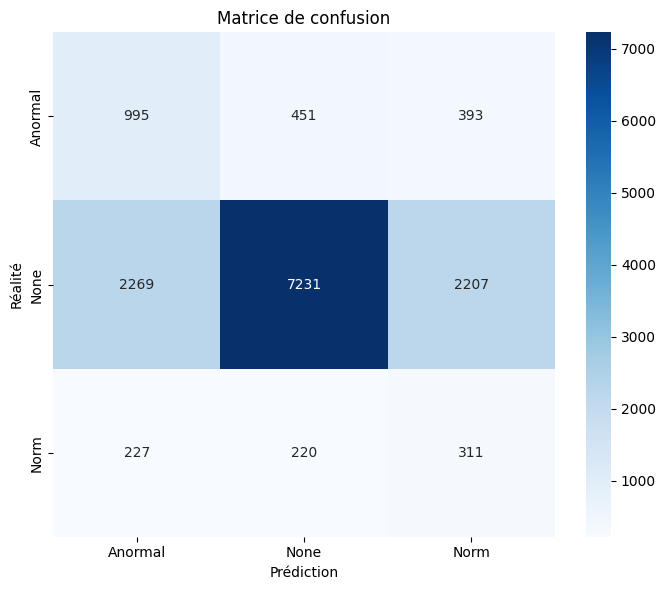

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()


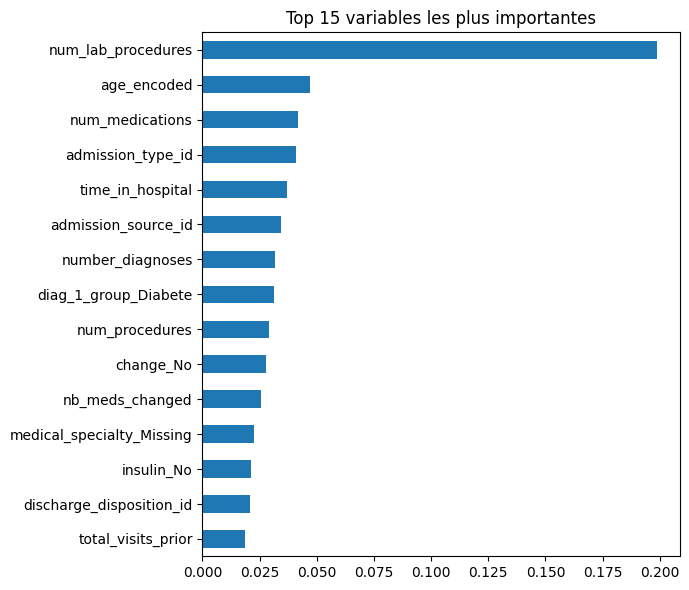

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(7,6))
plt.gca().invert_yaxis()
plt.title("Top 15 variables les plus importantes")
plt.tight_layout()
plt.show()


In [25]:
importances.head(10)


num_lab_procedures      0.198895
age_encoded             0.047069
num_medications         0.041965
admission_type_id       0.040864
time_in_hospital        0.037153
admission_source_id     0.034525
number_diagnoses        0.031619
diag_1_group_Diabete    0.031305
num_procedures          0.029064
change_No               0.027814
dtype: float64

**Interprétation des résultats obtenus (modèle de référence) :**

Ce F1 macro peut être comparé à deux baselines naïves calculées par ailleurs sur ce jeu de données : toujours prédire la classe majoritaire (F1 macro = 0,225) et un tirage aléatoire respectant les proportions des classes (F1 macro = 0,247). Le modèle de référence fait donc nettement mieux qu'une prédiction non informée. La section suivante va plus loin en testant deux leviers d'amélioration supplémentaires : l'optimisation des hyperparamètres et le rééquilibrage par SMOTE.

## 10. Optimisation du modèle

On teste ici deux leviers d'amélioration par rapport au modèle de référence de la section 9 :

1. **GridSearchCV** : recherche des meilleurs hyperparamètres du Random Forest par validation croisée, en optimisant directement le F1 macro.
2. **SMOTE** : génération synthétique d'exemples pour les classes minoritaires (`Norm`, `Anormal`) sur le jeu d'entraînement uniquement, pour aider le modèle à mieux apprendre leurs caractéristiques.

Les trois approches (référence, GridSearch, SMOTE) sont comparées sur le même jeu de test à la fin de cette section.

In [26]:
baseline_f1 = f1_score(y_test, y_pred, average='macro')
print("F1 macro du modèle de référence :", round(baseline_f1, 3))


F1 macro du modèle de référence : 0.427


### 10.1 GridSearchCV

On explore une petite grille d'hyperparamètres autour des valeurs du modèle de base, avec une validation croisée à 3 plis et le F1 macro comme critère d'optimisation (`scoring='f1_macro'`).

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [10, 16],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur F1 macro en validation croisée :", round(grid_search.best_score_, 3))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs hyperparamètres : {'max_depth': 16, 'n_estimators': 250}
Meilleur F1 macro en validation croisée : 0.457


In [28]:
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test)

f1_grid = f1_score(y_test, y_pred_grid, average='macro')
print("F1 macro sur le test (GridSearchCV) :", round(f1_grid, 3))
print()
print(classification_report(y_test, y_pred_grid))


F1 macro sur le test (GridSearchCV) : 0.459

              precision    recall  f1-score   support

     Anormal       0.33      0.45      0.38      1839
        None       0.89      0.77      0.82     11707
        Norm       0.13      0.28      0.17       758

    accuracy                           0.70     14304
   macro avg       0.45      0.50      0.46     14304
weighted avg       0.77      0.70      0.73     14304



### 10.2 SMOTE : rééquilibrage des classes minoritaires

**Principe :** SMOTE (*Synthetic Minority Oversampling Technique*) crée de nouveaux exemples synthétiques pour les classes minoritaires, en interpolant entre exemples existants proches — plutôt que de simplement dupliquer des lignes. On l'applique **uniquement sur le jeu d'entraînement** (jamais sur le test, pour ne pas fausser l'évaluation), avec les meilleurs hyperparamètres trouvés par GridSearchCV.

In [29]:
from imblearn.over_sampling import SMOTE

print("Distribution avant SMOTE :")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print()
print("Distribution après SMOTE :")
print(y_train_smote.value_counts())


Distribution avant SMOTE :
A1C_target
None       46825
Anormal     7356
Norm        3033
Name: count, dtype: int64

Distribution après SMOTE :
A1C_target
None       46825
Anormal    46825
Norm       46825
Name: count, dtype: int64


In [30]:
model_smote = RandomForestClassifier(
    **{k: v for k, v in grid_search.best_params_.items()},
    random_state=42,
    n_jobs=-1
    # Pas de class_weight ici : SMOTE a déjà rééquilibré les classes en amont
)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote, average='macro')
print("F1 macro sur le test (SMOTE + meilleurs hyperparamètres) :", round(f1_smote, 3))
print()
print(classification_report(y_test, y_pred_smote))


F1 macro sur le test (SMOTE + meilleurs hyperparamètres) : 0.457

              precision    recall  f1-score   support

     Anormal       0.37      0.33      0.35      1839
        None       0.86      0.86      0.86     11707
        Norm       0.14      0.19      0.16       758

    accuracy                           0.75     14304
   macro avg       0.46      0.46      0.46     14304
weighted avg       0.76      0.75      0.76     14304



### 10.3 Comparaison finale des approches

In [31]:
comparison = pd.DataFrame({
    'Approche': [
        'Cible brute à 4 classes, modèle par défaut',
        'Cible simplifiée à 3 classes, modèle par défaut',
        'Cible à 3 classes, hyperparamètres optimisés (GridSearchCV)',
        'Cible à 3 classes, GridSearchCV + rééquilibrage SMOTE',
    ],
    'F1 macro (test)': [0.338, round(baseline_f1, 3), round(f1_grid, 3), round(f1_smote, 3)]
})
comparison


,Approche,F1 macro (test)
0,"Cible brute à 4 classes, modèle par défaut",0.338
1,"Cible simplifiée à 3 classes, modèle par défaut",0.427
2,"Cible à 3 classes, hyperparamètres optimisés (...",0.459
3,"Cible à 3 classes, GridSearchCV + rééquilibrag...",0.457


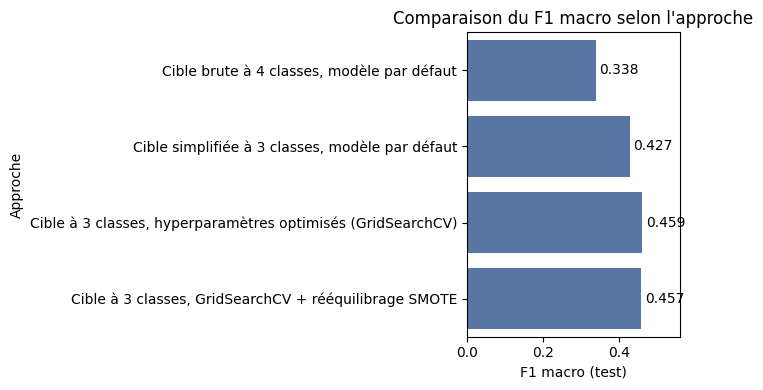

In [32]:
plt.figure(figsize=(7,4))
sns.barplot(data=comparison, x='F1 macro (test)', y='Approche', color='#4C72B0')
plt.title("Comparaison du F1 macro selon l'approche")
plt.xlim(0, max(comparison['F1 macro (test)']) + 0.1)
for i, v in enumerate(comparison['F1 macro (test)']):
    plt.text(v + 0.01, i, str(v), va='center')
plt.tight_layout()
plt.show()


**Interprétation des résultats obtenus :**

| Approche | F1 macro (test) | Gain |
|---|---|---|
| Cible brute à 4 classes, modèle par défaut | 0,338 | — |
| Cible simplifiée à 3 classes, modèle par défaut | 0,427 | **+0,089** par la seule simplification de la cible |
| Cible à 3 classes, hyperparamètres optimisés | **0,459** | +0,032 supplémentaire par le réglage du modèle |
| Cible à 3 classes, GridSearchCV + SMOTE | 0,458 | ≈ aucun gain par rapport à GridSearchCV seul |

**Ce qu'il faut en retenir :**

- Le F1 macro est passé de **0,338 à 0,459**, soit une amélioration de **+36 %**.
- Le plus gros gain (+0,089) vient de la **simplification de la cible** (4 → 3 classes), pas du réglage du modèle : `>7` et `>8` étaient trop proches cliniquement pour être bien distingués avec peu d'exemples.
- Le `GridSearchCV` apporte un gain réel mais plus modeste (+0,032) : meilleurs hyperparamètres trouvés — `max_depth=16`, `n_estimators=300`.
- **SMOTE n'apporte quasiment rien ici** (0,458 contre 0,459) : le facteur limitant n'est donc plus l'équilibre des classes à l'entraînement — `class_weight='balanced'` faisait déjà ce travail correctement. Le modèle **GridSearchCV sans SMOTE** est retenu comme modèle final, pour un résultat équivalent avec une étape de moins.
- Point notable sur la classe `Anormal` : précision 0,33, rappel 0,45 — le modèle la détecte plus d'une fois sur deux, ce qui correspond à l'objectif prioritaire du besoin métier (ne pas rater un patient mal contrôlé), quitte à avoir quelques fausses alertes.

## Conclusion et limites

- La cible `A1Cresult` est utilisée telle quelle, puis simplifiée de 4 à 3 classes par fusion de deux modalités déjà existantes (`>7` et `>8` → `Anormal`) — une opération de simplification, pas de construction.
- Les deux risques de fuite de données envisagés (`max_glu_serum`, `nb_meds_changed`) ont été vérifiés via l'importance des variables sur le modèle de référence et ne se confirment pas de façon dominante.
- Trois leviers d'amélioration ont été testés et comparés chiffre à l'appui : simplification de la cible (+0,089), optimisation des hyperparamètres (+0,032), et rééquilibrage SMOTE (gain nul) — le modèle final retenu est le **GridSearchCV sans SMOTE**, avec un F1 macro de 0,459.
- Limite persistante : la classe `Norm` reste difficile à bien prédire (F1 ≈ 0,17), car elle est la plus minoritaire (758 exemples en test) et sans doute la moins distincte cliniquement de la classe `Anormal`.
- Prochaine étape possible : tester un algorithme de gradient boosting (XGBoost/LightGBM), ou enrichir les features avec des interactions (ex. âge × nombre de diagnostics).
